<a href="https://colab.research.google.com/github/Aakash-77089/Computer-Vision/blob/main/Global%20Average%20Pooling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Load and Preprocess Data (CIFAR-10)

We'll use the CIFAR-10 dataset, which consists of 60,000 32x32 color images in 10 classes, with 6,000 images per class. There are 50,000 training images and 10,000 test images.

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, datasets
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# Get class names for visualization (optional)
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train images shape: (50000, 32, 32, 3)
Train labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


### 2. Build the CNN Model with Global Average Pooling (GAP)

Here, we define a CNN architecture. Notice how `GlobalAveragePooling2D` replaces the traditional `Flatten` layer and subsequent Dense layers before the final output layer. This significantly reduces the number of parameters and can help prevent overfitting.

In [3]:
# Define the CNN model using Sequential API
model_gap = models.Sequential([
    # Input layer
    layers.Input(shape=(32, 32, 3)),

    # Convolutional Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Convolutional Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Convolutional Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Global Average Pooling Layer
    # This layer takes the average of each feature map.
    # For a feature map of size HxWxD, it outputs a vector of size D.
    layers.GlobalAveragePooling2D(),

    # Output layer
    # Since CIFAR-10 has 10 classes, the output layer has 10 units
    # with a softmax activation for multi-class classification.
    layers.Dense(10, activation='softmax')
])

# Display the model summary to see the architecture and parameter count
model_gap.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 290,090 (1.11 MB)

 Trainable params: 289,194 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

### 3. Compile the Model

We compile the model by specifying the optimizer, loss function, and metrics. For multi-class classification with integer labels, `sparse_categorical_crossentropy` is appropriate.

In [4]:
model_gap.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### 4. Train the Model

Now, we train the model using the training data and validate it with the test data. Training will take some time depending on your hardware.

In [5]:
history = model_gap.fit(train_images, train_labels, epochs=10, # You can increase epochs for better accuracy
                    validation_data=(test_images, test_labels),
                    batch_size=64)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 504s 638ms/step - accuracy: 0.5467 - loss: 1.2616 - val_accuracy: 0.5217 - val_loss: 1.4139
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 481s 615ms/step - accuracy: 0.6923 - loss: 0.8710 - val_accuracy: 0.7421 - val_loss: 0.7516
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 499s 611ms/step - accuracy: 0.7468 - loss: 0.7225 - val_accuracy: 0.7362 - val_loss: 0.7585
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 474s 607ms/step - accuracy: 0.7787 - loss: 0.6360 - val_accuracy: 0.6933 - val_loss: 0.9324
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 494s 632ms/step - accuracy: 0.8012 - loss: 0.5724 - val_accuracy: 0.7941 - val_loss: 0.6086
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 495s 633ms/step - accuracy: 0.8164 - loss: 0.5238 - val_accuracy: 0.7991 - val_loss: 0.5823
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 475s 608ms/step - accuracy: 0.8325 - loss: 0.4795 - val_accuracy: 0.7846 - val_loss: 0.6434
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 474s 606ms/step - accuracy: 0.8441 -

### 5. Evaluate the Model

Finally, we evaluate the model's performance on the test set and visualize the training history.

313/313 - 23s - 72ms/step - accuracy: 0.8028 - loss: 0.5850

Test accuracy: 0.8027999997138977


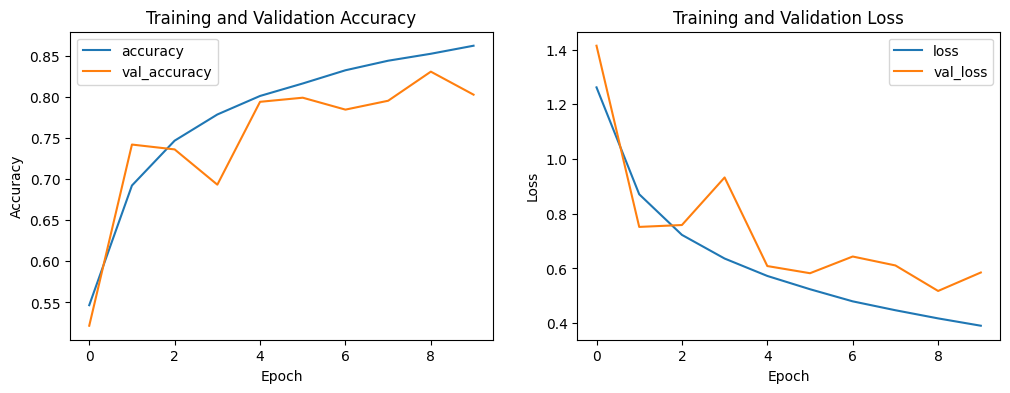

In [6]:
test_loss, test_acc = model_gap.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest accuracy: {test_acc}")

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()